In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import cv2
import os
import PIL
import tensorflow as tf 

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [4]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,cache_dir ='.', untar=True)

In [5]:
# convert Path to Windows path Object 

import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [17]:
# All images With Specific . extention / Specific Format

# list(data_dir.glob('*/*.jpg'))

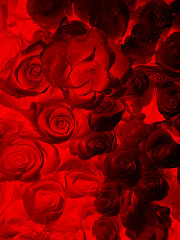

In [27]:
roses = list(data_dir.glob('roses/*'))       # showing ALl roses 
roses[:5]
PIL.Image.open(str(roses[4]))

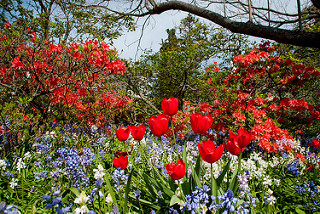

In [28]:
tulips = list(data_dir.glob('tulips/*'))   # all tulips 
PIL.Image.open(str(tulips[4]))             # Viewing Image Using Python PIL Library 

In [36]:
# Create a Dict for all the flowers path 

flowers_images_dict = {
    'roses' : list(data_dir.glob('roses/*')),
    'daisy' : list(data_dir.glob('daisy/*')),
    'dandelion' : list(data_dir.glob('dandelion/*')),
    'sunflowers' : list(data_dir.glob('sunflowers/*')), 
    'tulips' : list(data_dir.glob('tulips/*')), 
}

In [38]:
# flowers_images_dict['sunflowers']

In [40]:
# Create a label dict for each flower category
flowers_labels_dict = {
    'roses' : 0,
    'daisy' : 1,
    'dandelion': 2,
    'sunflowers' : 3,
    'tulips' : 4,
}

In [45]:
# Using CV2 to read the images in OpenCV obj or like in form of Numpy Array 

img = cv2.imread(str(flowers_images_dict['roses'][0]))    # wrap the windows path into a str as cv2 expect to read that like this way 
img.shape

(240, 179, 3)

In [46]:
# resizing img dimention

cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [49]:
x , y = [] , []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resize_img = cv2.resize(img,(180,180))
        x.append(resize_img)                          #-> x expects the 3D array of flower 
        y.append(flowers_labels_dict[flower_name])    # -> y expects the number code for flower 

In [52]:
x = np.array(x)
y = np.array(y)          # convereting this to a Numpy array 

### train test Split 

In [53]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y ,random_state = 0)

In [55]:
len(x_train)

2752

In [63]:
x_train_scaled = x_train /255
x_test_scaled = x_test / 255      # converting the array between 0 & 1 range

### Model building ----> A CNN

In [64]:
num_classes = 5

model = Sequential([
    layers.Conv2D(16,3 ,padding = 'same' , activation = 'relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3 ,padding = 'same' , activation = 'relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3 ,padding = 'same' , activation = 'relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
        layers.Dense(128 , activation = 'relu'),
        layers.Dense(num_classes)
])

model.compile(optimizer = 'adam',
             loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
             metrics = ['accuracy'])

model.fit(x_train_scaled, y_train , epochs = 30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 0.4477 - loss: 1.2822
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 0.5970 - loss: 1.0202
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 0.6933 - loss: 0.8167
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 174ms/step - accuracy: 0.7747 - loss: 0.6128
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 177ms/step - accuracy: 0.8605 - loss: 0.4074
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 175ms/step - accuracy: 0.9277 - loss: 0.2176
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 176ms/step - accuracy: 0.9622 - loss: 0.1376
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 175ms/step - accuracy: 0.9884 - loss: 0.0566
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 175ms/step - accuracy: 0.9884 - loss: 0.0451
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 176ms/step - accuracy: 0.9942 - loss: 0.0309
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 175ms/step - accuracy: 0.9935 - loss: 0.0264
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15

## 99 % accuracy

In [65]:
# Let's try on test Dataset 

model.evaluate(x_test_scaled, y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.6449 - loss: 2.3511  


[2.3511457443237305, 0.6448801755905151]

###### This is a example of OVERFITTING

In [66]:
predictions = model.predict(x_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step 


array([[  1.0970458 ,  20.75981   ,   2.9977565 ,  -6.8563075 ,
         -5.9676824 ],
       [  9.179565  ,   1.76847   , -10.052243  ,  -3.7564328 ,
          4.314526  ],
       [ -5.2820077 ,   7.352179  ,  13.990216  ,  -5.590825  ,
         -2.7917037 ],
       ...,
       [  2.26307   ,  -4.2750845 ,  -7.5531564 ,  14.486929  ,
          3.7206538 ],
       [  3.5150526 ,   6.2341056 ,  -0.92392284,  -2.7416067 ,
         -2.558515  ],
       [  0.16544256,  -8.72889   ,  -1.2392524 ,   7.540064  ,
          4.585978  ]], dtype=float32)

In [67]:
score = tf.nn.softmax(predictions[0])
score

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([2.8878213e-09, 1.0000000e+00, 1.9321403e-08, 1.0150152e-12,
       2.4683005e-12], dtype=float32)>

In [68]:
np.argmax(score)

np.int64(1)

In [69]:
y_test[0]

np.int64(1)

### Now We will apply data Augmentation 

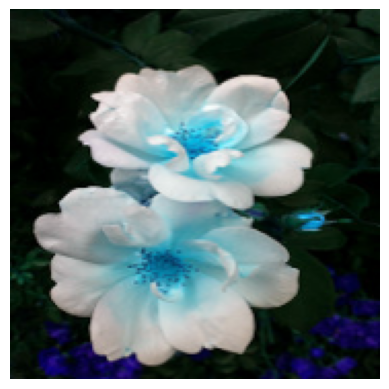

In [78]:
plt.axis('off')
plt.imshow(x[0])

### Single transformation

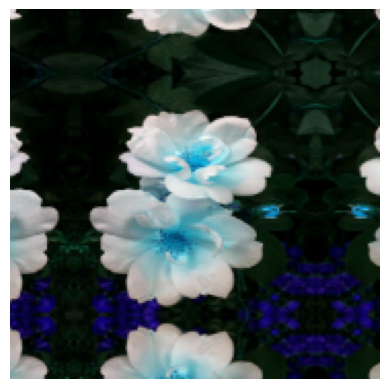

In [94]:
data_augmentation = keras.Sequential([
    layers.RandomZoom(0.9),
])                                                                            # ZOOM
plt.axis('off')
plt.imshow(data_augmentation(x)[0].numpy().astype("uint8"))

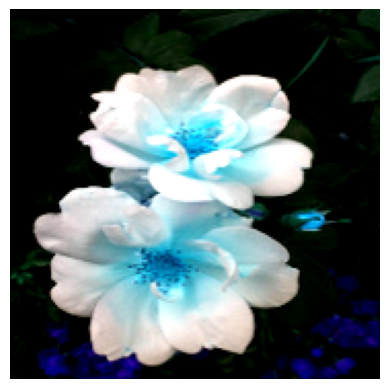

In [95]:
data_augmentation = keras.Sequential([
    layers.RandomContrast(0.9),
])                                                                   #CONTRAST
plt.axis('off')
plt.imshow(data_augmentation(x)[0].numpy().astype("uint8"))

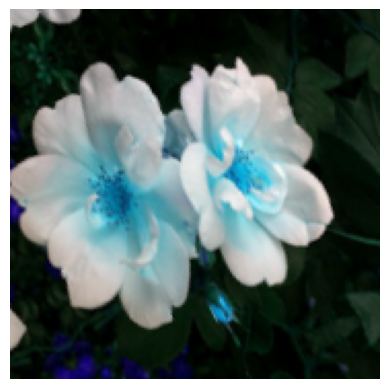

In [96]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.9),
])                                                                        #ROTATION
plt.axis('off')
plt.imshow(data_augmentation(x)[0].numpy().astype("uint8"))

### Multiple Transformations

In [100]:
img_height = 180
img_width = 180

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal",
                      input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

D:\AI-ML\software\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### New Model with data Augmentation

In [101]:
num_classes = 5

model = Sequential([
    data_augmentation,
    layers.Conv2D(16,3 ,padding = 'same' , activation = 'relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3 ,padding = 'same' , activation = 'relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3 ,padding = 'same' , activation = 'relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
        layers.Dense(128 , activation = 'relu'),
        layers.Dense(num_classes)
])

model.compile(optimizer = 'adam',
             loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
             metrics = ['accuracy'])

model.fit(x_train_scaled, y_train , epochs = 30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 217ms/step - accuracy: 0.4484 - loss: 1.3282
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 217ms/step - accuracy: 0.5814 - loss: 1.0557
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 215ms/step - accuracy: 0.6163 - loss: 0.9729
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 215ms/step - accuracy: 0.6682 - loss: 0.8703
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 214ms/step - accuracy: 0.6890 - loss: 0.8072
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 214ms/step - accuracy: 0.7089 - loss: 0.7711
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 215ms/step - accuracy: 0.7289 - loss: 0.7085
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 214ms/step - accuracy: 0.7336 - loss: 0.7035
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 215ms/step - accuracy: 0.7406 - loss: 0.6768
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 227ms/step - accuracy: 0.7562 - loss: 0.6348
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 215ms/step - accuracy: 0.7747 - loss: 0.6131
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 18

In [102]:
model.evaluate(x_test_scaled, y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.7244 - loss: 1.0314  


[1.0314054489135742, 0.7244008779525757]